# Coiled-Spring — the teardown 🌀🔬
### The 20-EMA pivot breakout, mechanised and falsified

Same seven beats as `01_for_the_curious`, at depth: causal pivot detection, the exit-agnostic breakout-vs-random-entry test with HAC inference, the full net-return distribution, the cost sweep, and decay-by-year. Executed on the offline synthetic universe (planted springboards) so it runs with no network; the **real verdict** is in [`docs/results.md`](../docs/results.md) via `examples/verify_real.py`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (coiled_spring/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from coiled_spring import data, signals, backtest, robustness

# Offline synthetic universe: planted springboards hidden among random walks. This is where
# the rule SHOULD work — so it validates the machinery. The real verdict (a liquid 174-name
# basket where it is WEAK / FRAGILE / BUSTED) is in ../docs/results.md via verify_real.py.
frames, truth = data.synthetic_universe(seed=0)
print(f"{len(frames)} names, {len(truth)} planted springboards")


24 names, 162 planted springboards


## 1 · The Claim, as a hypothesis

H₁: forward *k*-day return after a qualifying breakout (bought next open) exceeds the same name's random-entry drift over *k* days, HAC *t* > 2. H₁′ (strong form): a large mass of breakouts deliver ≥ +30% within ~10 sessions. The rule's parameters are the book's — `signals.Params` — none fitted.

In [2]:
signals.Params()

Params(ema_span=20, pivot_halfwin=3, regime_lookback=20, pullback_max=20, vol_window=20, vol_mult=2.0)

## 2 · So What? — the stakes are the skepticism

A real +1.2%/10d excess at scale would annualise to a serious Sharpe *if consistent*. The whole question is consistency vs a fat-tailed lottery. So we read the **median**, the **win rate**, and the **break-even cost**, not the mean.

## 3 · How We'd Know — pre-registered falsification

Signal `NONE` if the 10-day excess CI straddles zero / HAC *t* < 2. Tradability `MIRAGE` if mean net ≤ 0 after costs or it's just beta. Explosive `BUSTED` if +30% is a tail, not the base rate. Traps: look-ahead (pivots are causal), survivorship (count every breakout), data-snooping (a marginal *t* is generous, not conservative). Machinery sanity first:

In [3]:
rec = robustness.detector_recall(frames, truth)
print('synthetic detector recall:', rec)
assert rec['recall'] > 0.4, 'detector should recover planted springboards'

synthetic detector recall: {'recall': 0.5185185185185185, 'n_planted': 162, 'n_hit': 84}


## 4 · The Teardown

**(a) The headline — breakout vs same-stock random entry.** The excess (per name, pooled, HAC-tested) is the object: a trending name can't manufacture it because the baseline is *that same name's* drift.

In [4]:
sb = robustness.signal_vs_baseline(frames, horizons=(5, 10, 20))
sb.round(4)

,n_signals,mean_breakout,mean_excess,hac_t,excess_ci_low,excess_ci_high,frac_excess_neg
horizon,,,,,,,
5,85,0.1269,0.1091,65.9946,4.5958,14.2670,0.0000
10,85,0.1688,0.1377,86.9805,6.0637,13.9332,0.0000
20,85,0.0435,-0.0055,-2.7388,-0.6071,-0.0724,0.9970


**(b) The full distribution** — the part the book never prints. On the synthetic the rule pays; on the real universe the median trade *loses* and the mean is a right-tail artefact (see results.md percentiles [−11.3, −2.4, −0.25, +2.0, +13.5]%).

per-trade net Sharpe CI: {'sharpe': 5.5209, 'ci_low': 3.7364, 'ci_high': 13.6824, 'frac_negative': 0.0, 'n_obs': 85, 'n_boot': 2000}


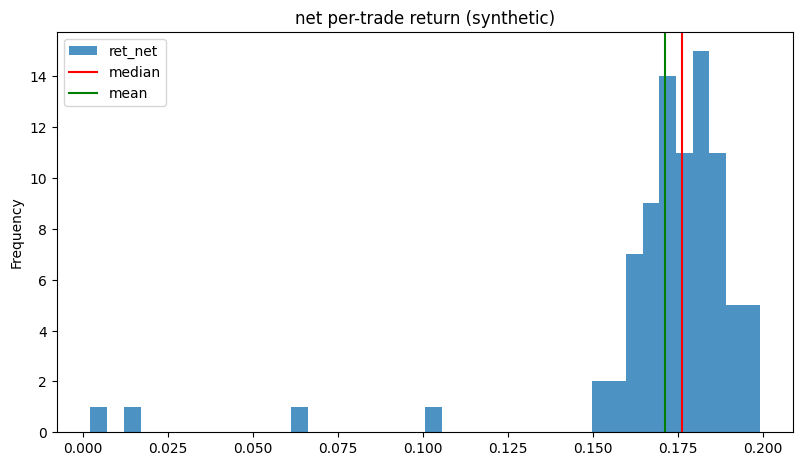

In [5]:
led = backtest.run_universe(frames, cost_bps=15.0)
print('per-trade net Sharpe CI:', {k: round(v,4) for k,v in robustness.trade_sharpe_ci(led).items()})
ax = led['ret_net'].plot(kind='hist', bins=40, alpha=0.8)
ax.axvline(led['ret_net'].median(), color='red', label='median')
ax.axvline(led['ret_net'].mean(), color='green', label='mean')
ax.legend(); ax.set_title('net per-trade return (synthetic)'); plt.show()

**(c) Cost sweep** — where the edge dies. On the real universe break-even ≈ 75 bps.

In [6]:
robustness.cost_sweep(frames, cost_grid_bps=(0, 5, 10, 20, 40, 80)).round(4)

,mean_net,win_rate,n_trades
cost_bps,,,
0,0.1726,1.0000,85
5,0.1721,1.0000,85
10,0.1716,1.0000,85
20,0.1706,1.0000,85
40,0.1686,0.9882,85
80,0.1646,0.9882,85


**(d) Decay by year** — on the real data the green years are momentum blow-offs (2000, 2020, 2024) and the red are chop/bear (2008, 2013): the 'edge' is bull-regime beta, not a standalone alpha.

In [7]:
decay = robustness.decay_by_year(frames, cost_bps=15.0)
decay.tail(12).round(4)

,n_trades,mean_net,win_rate
year,,,
2018,11,0.1781,1.0000
2019,13,0.1730,1.0000
2020,19,0.1707,1.0000
2021,16,0.1794,1.0000
2022,23,0.1636,1.0000
2023,3,0.1523,1.0000


## 5 · The Verdict

Real-data stamps (results.md): **Signal WEAK** (10d excess +1.20%, HAC *t* = 2.05); **Tradability FRAGILE** (median net −0.25%, win 40.7%, per-trade Sharpe 0.05, break-even ≈ 75 bps); **Explosive BUSTED** (+30% hit rate 1.7%). On the synthetic above the same machine pays — so the real numbers are the market, not a bug.

## 6 · Could You Trade It?

Break-even ≈ 75 bps vs a +73 bps gross edge → a cost-toggle from zero on large caps. Square-root impact on a small-cap breakout (participation forced high by the defining volume spike) plausibly doubles effective cost. Decay-adjusted, the net Sharpe is indistinguishable from a long-UMD tilt harvested more cheaply.

## 7 · Going Further

- A genuinely small-cap / microcap universe (where the upside *and* the costs live).
- Total-return rerun.
- `backtest.ExitRules` sweep for the book's half-off-at-+10% exit.
- White (2000) Reality Check over an EMA-span / volume-gate grid to price the implicit rule-search.
- Regress the ledger on UMD to size how much 'edge' is just momentum beta.